### Load Dependencies

In [2]:
import pandas as pd
import pickle
from sklearn.preprocessing import OneHotEncoder

### Load CSV

In [3]:
df = pd.read_csv("Data/city_day.csv")
df.head(5)
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

### Information of Data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [5]:
df.head(5)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [6]:
column_types = df.dtypes
print("\nData Types:\n", column_types)


Data Types:
 City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object


In [7]:
print(df['City'])

0            Ahmedabad
1            Ahmedabad
2            Ahmedabad
3            Ahmedabad
4            Ahmedabad
             ...      
29526    Visakhapatnam
29527    Visakhapatnam
29528    Visakhapatnam
29529    Visakhapatnam
29530    Visakhapatnam
Name: City, Length: 29531, dtype: object


### Check null values

In [8]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [9]:
def fillna_with_mean(df):
    """fill the NaN values with the coloumn mean value"""
    exe_col = ['City', 'Date', 'AQI_Bucket']
    num_col = df.select_dtypes(include=['int64', 'float64']).columns
    num_col = [col for col in num_col if col not in exe_col]
    for col in num_col:
        mean = df[col].mean()
        df[col] = df[col].fillna(mean)
    return df

In [10]:
df = fillna_with_mean(df)

### Create Feature Set

In [11]:
x1 = df.iloc[:,:14].values
x1.shape

(29531, 14)

In [12]:
x1[0]

array(['Ahmedabad', '2015-01-01', 67.45057794890307, 118.12710293078135,
       0.92, 18.22, 17.15, 23.483476019371977, 0.92, 27.64, 133.36, 0.0,
       0.02, 0.0], dtype=object)

In [13]:
y1 = df.iloc[:,14:15].values
y1.shape

(29531, 1)

In [14]:
z1 = pd.DataFrame(x1, columns=df.columns[:14])
z1.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene
0,Ahmedabad,2015-01-01,67.450578,118.127103,0.92,18.22,17.15,23.483476,0.92,27.64,133.36,0.0,0.02,0.0
1,Ahmedabad,2015-01-02,67.450578,118.127103,0.97,15.69,16.46,23.483476,0.97,24.55,34.06,3.68,5.5,3.77
2,Ahmedabad,2015-01-03,67.450578,118.127103,17.4,19.3,29.7,23.483476,17.4,29.07,30.7,6.8,16.4,2.25
3,Ahmedabad,2015-01-04,67.450578,118.127103,1.7,18.48,17.97,23.483476,1.7,18.59,36.08,4.43,10.14,1.0
4,Ahmedabad,2015-01-05,67.450578,118.127103,22.1,21.42,37.76,23.483476,22.1,39.33,39.31,7.01,18.89,2.78


In [15]:
# drop date colume
z1=z1.drop(["Date"], axis=1)

In [16]:
z1.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene
0,Ahmedabad,67.450578,118.127103,0.92,18.22,17.15,23.483476,0.92,27.64,133.36,0.0,0.02,0.0
1,Ahmedabad,67.450578,118.127103,0.97,15.69,16.46,23.483476,0.97,24.55,34.06,3.68,5.5,3.77
2,Ahmedabad,67.450578,118.127103,17.4,19.3,29.7,23.483476,17.4,29.07,30.7,6.8,16.4,2.25
3,Ahmedabad,67.450578,118.127103,1.7,18.48,17.97,23.483476,1.7,18.59,36.08,4.43,10.14,1.0
4,Ahmedabad,67.450578,118.127103,22.1,21.42,37.76,23.483476,22.1,39.33,39.31,7.01,18.89,2.78


In [17]:
x1 = z1.iloc[:,0:13].values
z1 = pd.DataFrame(x1)

In [18]:
z1.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Ahmedabad,67.450578,118.127103,0.92,18.22,17.15,23.483476,0.92,27.64,133.36,0.0,0.02,0.0
1,Ahmedabad,67.450578,118.127103,0.97,15.69,16.46,23.483476,0.97,24.55,34.06,3.68,5.5,3.77
2,Ahmedabad,67.450578,118.127103,17.4,19.3,29.7,23.483476,17.4,29.07,30.7,6.8,16.4,2.25
3,Ahmedabad,67.450578,118.127103,1.7,18.48,17.97,23.483476,1.7,18.59,36.08,4.43,10.14,1.0
4,Ahmedabad,67.450578,118.127103,22.1,21.42,37.76,23.483476,22.1,39.33,39.31,7.01,18.89,2.78


In [19]:
z1[0].nunique()

26

### Final Feature Set

In [20]:
ohe = OneHotEncoder(drop='first')
x_new1 = pd.DataFrame(ohe.fit_transform(x1[:,[0]]).toarray()) #state
feature_set = pd.concat([x_new1,pd.DataFrame(z1.iloc[:,1:].values)],axis=1,sort=False)

In [21]:
ohe.transform([["Ahmedabad"]])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 0 stored elements and shape (1, 25)>

In [22]:
import pickle
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# example city data
cities = ['Ahmedabad', 'Mumbai', 'Delhi', 'Chennai', 'Bangalore']

# convert to dataframe
df = pd.DataFrame(cities, columns=['City'])

# create encoder
ohe = OneHotEncoder()

# fit encoder
ohe.fit(df[['City']])

# save encoder
pickle.dump(ohe, open("Models/OneHotEncoder_Featureset.pkl", "wb"))

In [23]:
import pickle

pickle.dump(ohe, open("Models/OneHotEncoder_Featureset.pkl", "wb"))

In [24]:
feature_set

,0,1,2,3,4,5,6,7,8,9,...,2,3,4,5,6,7,8,9,10,11
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.92,18.22,17.15,23.483476,0.92,27.64,133.36,0.0,0.02,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.97,15.69,16.46,23.483476,0.97,24.55,34.06,3.68,5.5,3.77
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,17.4,19.3,29.7,23.483476,17.4,29.07,30.7,6.8,16.4,2.25
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.7,18.48,17.97,23.483476,1.7,18.59,36.08,4.43,10.14,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,22.1,21.42,37.76,23.483476,22.1,39.33,39.31,7.01,18.89,2.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.68,25.06,19.54,12.47,0.47,8.55,23.3,2.24,12.07,0.73
29527,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38
29528,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.0
29529,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.05,29.26,18.8,10.03,0.52,9.84,28.3,0.0,0.0,0.0


### Model Training

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [26]:
x_train,x_test,y_train,y_test = train_test_split(feature_set,y1,test_size=0.25,random_state=0)

In [27]:

# multiple linear regression model
mreg = LinearRegression()
mreg.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
y_predict = mreg.predict(x_test)

In [29]:
mreg.score(x_test, y_test)

0.7976949966187843

### df2 = pd.DataFrame({'Actual': y_test, 'Predicted':y_predict}) 

In [30]:
print (df) 
from matplotlib import pyplot as plt
#Visualize the best fit line
#df['Date'] = pd.to_datetime(df['Date'])
#df['year'] = df['Date'].dt.year
#year=df['year']

        City
0  Ahmedabad
1     Mumbai
2      Delhi
3    Chennai
4  Bangalore


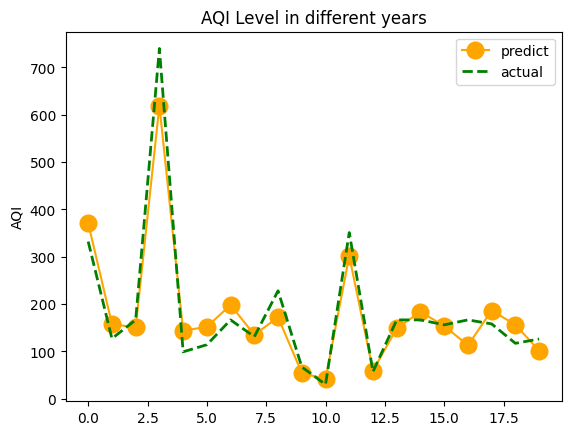

In [31]:
plt.plot(y_predict[:20],color ='orange', 
         marker ='o', markersize = 12,  
         label ='predict')
plt.plot(y_test[:20],color ='g', 
         linestyle ='dashed', linewidth = 2, 
         label ='actual')
plt.title('AQI Level in different years') 
plt.ylabel('AQI')
plt.legend() 
plt.show()

### polynomial regression model
### degree = 2

In [32]:
# make sure you test polynomial regression, first transform the data with 2 degree.
poly_reg = PolynomialFeatures(degree = 2)
preg = LinearRegression()
pf = poly_reg.fit_transform(x_train)
preg.fit(pf,y_train)

pr_y_predict = preg.predict(poly_reg.fit_transform(x_test))

In [33]:
preg.score(poly_reg.fit_transform(x_test), y_test)

0.8504099064513955

In [34]:
pickle.dump(poly_reg, open("Models/ploy_reg.pkl",'wb'))

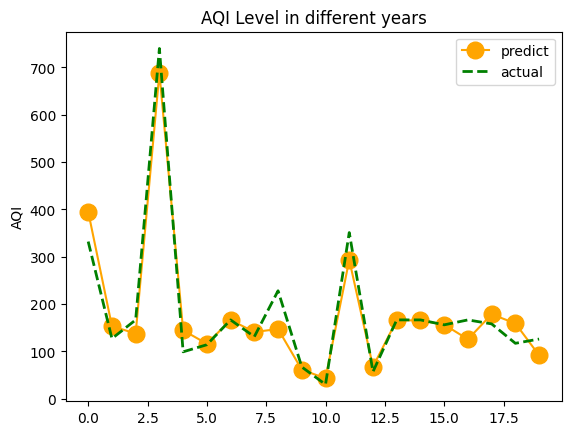

In [35]:
plt.plot(pr_y_predict[:20],color ='orange', 
         marker ='o', markersize = 12,  
         label ='predict')
plt.plot(y_test[:20],color ='g', 
         linestyle ='dashed', linewidth = 2, 
         label ='actual')
plt.title('AQI Level in different years') 
plt.ylabel('AQI')
plt.legend() 
plt.show()

# Decision tree regression model

In [36]:
dec_tree = DecisionTreeRegressor(random_state = 0)
dec_tree.fit(x_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_le

In [37]:
dt_y_predict = dec_tree.predict(x_test)

In [38]:
dec_tree.score(x_test, y_test)

0.7828400201839768

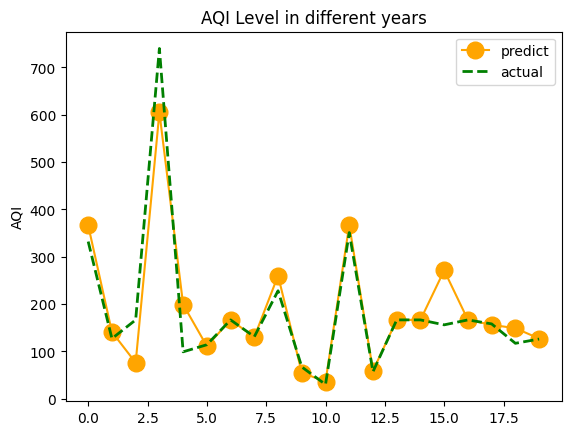

In [39]:
plt.plot(dt_y_predict[:20],color ='orange', 
         marker ='o', markersize = 12,  
         label ='predict')
plt.plot(y_test[:20],color ='g', 
         linestyle ='dashed', linewidth = 2, 
         label ='actual')
plt.title('AQI Level in different years') 
plt.ylabel('AQI')
plt.legend() 
plt.show()

# random forest regression model

In [40]:
from sklearn.ensemble import RandomForestRegressor

# Reshape the target variable y_train and y_test
y_train_reshaped = y_train.ravel()
y_test_reshaped = y_test.ravel()

# Create and train the Random Forest Regressor
rt_reg = RandomForestRegressor(n_estimators=500, random_state=0)
rt_reg.fit(x_train, y_train_reshaped)

# Make predictions
rt_y_predict = rt_reg.predict(x_test)


In [41]:
rt_reg = RandomForestRegressor(n_estimators = 500, random_state = 0)
rt_reg.fit(x_train,y_train)
rt_y_predict = rt_reg.predict(x_test)

c:\Users\KIIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [42]:
rt_reg.score(x_test, y_test)

0.8789923046690048

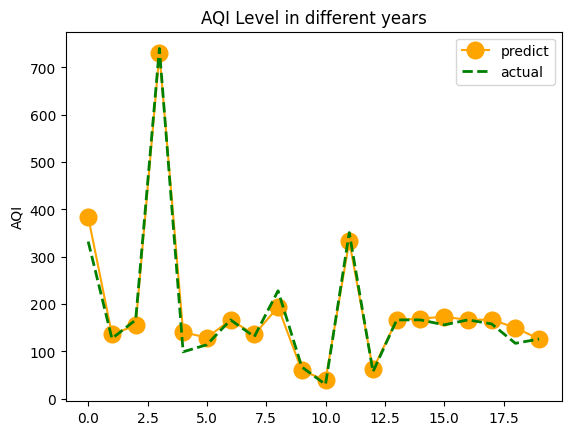

In [43]:
plt.plot(rt_y_predict[:20],color ='orange', 
         marker ='o', markersize = 12,  
         label ='predict')
plt.plot(y_test[:20],color ='g', 
         linestyle ='dashed', linewidth = 2, 
         label ='actual')
plt.title('AQI Level in different years') 
plt.ylabel('AQI')
plt.legend() 
plt.show()

In [44]:
# --- feature scaling the paramenters for better results ---

In [45]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
sc_y = StandardScaler()
x_train_svr = sc_x.fit_transform(x_train)
# y_train_svr = sc_y.fit_transform(y_train)

In [46]:
pickle.dump(sc_x, open("Models/Standard_Scaler_X_SVR.pkl",'wb'))

In [47]:
svr_reg = SVR()
svr_reg.fit(x_train_svr,y_train)

c:\Users\KIIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [48]:
x_test.shape

(7383, 37)

In [49]:
sc_x.transform(x_test).shape

(7383, 37)

In [50]:
svr_y_predict = svr_reg.predict(sc_x.transform(x_test))

In [51]:
svr_reg.score(sc_x.transform(x_test), y_test)

0.5577245020965855

In [52]:
# svr_y_predict = sc_y.inverse_transform(svr_reg.predict(sc_x.transform(x_test))) 

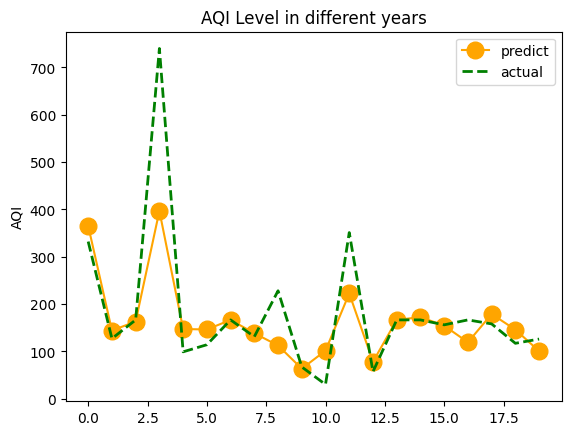

In [53]:
plt.plot(svr_y_predict[:20],color ='orange', 
         marker ='o', markersize = 12,  
         label ='predict')
plt.plot(y_test[:20],color ='g', 
         linestyle ='dashed', linewidth = 2, 
         label ='actual')
plt.title('AQI Level in different years') 
plt.ylabel('AQI')
plt.legend() 
plt.show()

# Use the loaded pickled model to make predictions 

In [54]:
import pickle

In [55]:
pickle.dump(mreg, open("Models/Multiple Regression.pkl",'wb'))
pickle.dump(preg, open("Models/pregression.pkl",'wb'))
pickle.dump(dec_tree, open("Models/Decision tree.pkl",'wb'))
pickle.dump(rt_reg, open("Models/RandomForest.pkl",'wb'))
pickle.dump(svr_reg, open("Models/svrression.pkl",'wb'))

### Load Pickle Model

In [56]:
with  open("Models/pregression.pkl",'rb') as model:
    pregression = pickle.load(model)

In [57]:
# Load model from file
# pregression.predict(x_test) 
pregression.predict(poly_reg.fit_transform(x_test))

array([[395.15743477],
       [153.24024515],
       [137.64345336],
       ...,
       [508.61724795],
       [ 64.9095958 ],
       [359.86386496]], shape=(7383, 1))

In [58]:
pregression.score(poly_reg.fit_transform(x_test), y_test)

0.8504099064513955

### Develope Streamlit

In [59]:
import streamlit as st

model_list = ['MR', 'PR', 'DTR', 'RF', 'SVR']

# initialize variable
selected = []

# checkbox + multiselect
if st.checkbox('Select columns to show'):
    selected = st.multiselect('Select', model_list)

# output
st.write(selected)

2026-03-12 17:12:49.849 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-12 17:12:49.850 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-12 17:12:49.851 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-12 17:12:49.851 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-12 17:12:50.583 
  command:

    streamlit run C:\Users\KIIT\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-12 17:12:50.583 Thread 'MainThread': missing ScriptRunContext! This warning ca